[author] 
CNN Lab CS4330 Computer Vision
Professor Kolsch

# Convolutional Neural Networks

This lab assignment accompanies the CS4330 "CNN, RNN, LSTM" module. The lab learning objectives are:
* Build and train a simple convolutional neural network (CNN) from scratch with PyTorch.
* Contrast the training and learning performance of the CNN to the unstructured NN from the last assignment.
* Obtain a pre-built CNN model and inspect:
    * the architecture,
    * the filter weights,
    * activations ("codes") at two layers for test images from known classes with t-SNE.
* Transfer-learn with this model to recognize an object of your choosing.

In [4]:
# one-time prep work
%matplotlib inline
import random
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [5]:
## Load the same image matrix as in the previous assignment.
img = cv.imread('digits.png')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
cells = [np.hsplit(row,100) for row in np.vsplit(gray,50)]
x = np.array(cells)

# Prepare the training data and test data including labels
train = x[:,:50].reshape(-1,400).astype(np.float32) # Size = (2500,400) with 400=20x20 pixels
test = x[:,50:100].reshape(-1,400).astype(np.float32) # Size = (2500,400)
k = np.arange(10)
train_labels = np.repeat(k,250)[:,np.newaxis]
test_labels = train_labels.copy()

# Convert numpy arrays to PyTorch tensors
train_tensor = torch.tensor(train)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long).squeeze()
test_tensor = torch.tensor(test)
test_labels_tensor = torch.tensor(test_labels,dtype=torch.long).squeeze()  

# Create datasets
train_dataset = TensorDataset(train_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_tensor, test_labels_tensor)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Print dataset sizes
print(f"Training set size: {len(train_dataset)} samples")
print(f"Test set size: {len(test_dataset)} samples")
print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

# Show an example batch
sample_batch = next(iter(train_loader))
print(f"Sample batch - Features shape: {sample_batch[0].shape}, Labels shape: {sample_batch[1].shape}")

Training set size: 2500 samples
Test set size: 2500 samples
Number of batches in train_loader: 40
Number of batches in test_loader: 40
Sample batch - Features shape: torch.Size([64, 400]), Labels shape: torch.Size([64])


## Create a Convolutional Neural Network
Using Pytorch, create a basic CNN of a shape/architecture that you think might work well for classifying this data.

Then: 
4. Modify the CNN in some fashion and observe the difference in train-test performance. Change the number of layers and change the size of convolutions. Add or remove max pool layers. You should try at least 5 different architectures.
5. Comment on what seems to work, what doesn't work so well, and hypothesize why.
6. Contrast the CNN performance to the FC NN performance from the last assignment (in prose).

In [6]:
# Define model
#CNNs automatically extract patterns and features from images
#ddep learning a subset of ML, where the model takes inputs, hidden layers, and gives outputs
#citation: https://www.datacamp.com/tutorial/pytorch-cnn-tutorial
class NeuralNetwork(nn.Module):
    def __init__(self, num_in_channels, num_classes_predict):
        #with pytorch, init creates the learnable components/forward function defines the how the data flows through the components 
        #this is grayscale for digits so in channels will be 1d
        #going to define all of the layers as attributes of the nn
        super(NeuralNetwork,self).__init__()
        #cnns have layers of convolutional layer (the application of a sliding window function (the filter/kernel) over a matrix of pixels representing an image)
        #then we apply a relu activation function after each convolutions to learn non-linear relationships between the features the kernel finds
        #then we pool which pulls the most significant features from the convoluted matrix (armgax)
        
        #convolutional layers
        self.conv1_layer = nn.Conv2d(in_channels=num_in_channels,out_channels=16,kernel_size=3,padding=1) #8-32 out channels is typical to learn basic features
        #padding = kernel_size // 2
        #you get 16 separate 3x3 filters each with different random starting weights (from the outchannel param)
        # each filter gets random initial weights and during training optimizer updates each filter 
        # since they start from different points they get different gradient updates during backpropagation
        # they naturally specialize through training
        # filter 1 might learn to detect vert edges
        #filter2 might learn to detect horizontal edges, filter 3 might learn to detect curves,etc.
        self.conv2_layer = nn.Conv2d(in_channels=16, out_channels=32,kernel_size=3,padding=1)
        #pooling layer
        
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        #activation layer
        self.relu = nn.ReLU() #max(o,x)
        #fully connected layers 20x20/2 -> 10x10/2 -> 5x5
        self.fc_layer1 = nn.Linear(in_features=32*5*5,out_features=128) #yhat = xA^T (800) + B (128x1), 128 usually a good middle ground z size (800x128 params)
        self.fc_layer2 = nn.Linear(in_features=128,out_features=10) #128x10
    
    def forward(self, x):
        '''x is the input tensor
        returns torch.tensor'''
        x = x.view(-1,1,20,20) #tensor.view(newshape) (tensor[3] vector with 3 elements, tensor[3,3] matrix with 3rowsx3cols, tensor[3,3,3] is 3batchesx3rowsx3cols)
        #we reshape here to (batch,1,20,20) because CNNs need spatial structure (20x20) not a flat vector of (400)
        #first conv
        x = self.conv1_layer(x) #-> 64,16,20,20 using 3x3 filters
        x = self.relu(x)
        x = self.pool(x) #-> 64,16,10,10, done do reduce parameters in next layers, provide translation invariance, extract dominant features
        #second conv
        x = self.conv2_layer(x) #-> 64,32,10,10
        x = self.relu(x)
        x = self.pool(x) #-> 64,32,5,5
        
        x=x.view(-1,32*5*5) #-> 64,800
        x = self.fc_layer1(x) #->64,128
        x=self.relu(x)
        x=self.fc_layer2(x) #->64,10, gives us 10 logits, highest number is prediction of digit

        return x        
#make modifications to the CNN to make 5 different architectures
#1. ShallowCNN (1 conv layer)
class ShallowCNN(nn.Module):
    '''Input:        (64, 1, 20, 20)   ← 64 grayscale images
Conv1:        (64, 16, 20, 20)  ← 16 feature maps per image
Pool:         (64, 16, 10, 10)  ← pooled down to 10×10
Flatten:      (64, 1600)        ← reshape for FC layer
FC1:          (64, 128)         ← optional hidden layer
FC2:          (64, 10)          ← 10 digit predictions
separate:
when definig layers (nn.linear(in_features=1600,out_features=128)
when running data: x.shape = 64,1500 ... x = fc1(x) .... x.shape(64,128) so 64 images with 128 features each)'''
    def __init__(self, num_in_channels):
        super(ShallowCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=num_in_channels, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(in_features=16*10*10, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        x = x.view(-1, 1, 20, 20)
        x = self.conv1(x)   # -> (64, 16, 20, 20)
        x = self.relu(x)
        x = self.pool(x)    # -> (64, 16, 10, 10)
        x = x.view(-1, 16*10*10)  # -> (64, 1600)
        x = self.fc1(x)     # -> (64, 128)
        x = self.relu(x)
        x = self.fc2(x)     #-> (64, 10)
        return x

class DeepCNN(nn.Module):
    def __init__(self, num_in_channels):
        super(DeepCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=num_in_channels, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(in_features=64*2*2, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=164)
        self.fc3 = nn.Linear(in_features=164,out_features=10)

    def forward(self, x):
        x = x.view(-1,1,20,20) #tensor.view(newshape) (tensor[3] vector with 3 elements, tensor[3,3] matrix with 3rowsx3cols, tensor[3,3,3] is 3batchesx3rowsx3cols)
        #we reshape here to (batch,1,20,20) because CNNs need spatial structure (20x20) not a flat vector of (400)
        #first conv
        x = self.conv1(x) #-> 64,16,20,20 using 3x3 filters
        x = self.relu(x)
        x = self.pool(x) #->64,16,10,10
        x = self.conv2(x) #->64,32,10,10
        x = self.relu(x) 
        x = self.pool(x) #->64,32,5,5
        x = self.conv3(x) #64,64,5,5
        x = self.relu(x)
        x = self.pool(x) #64,64,2,2
    
        x=x.view(-1,64*2*2) #-> 64,800
        x = self.fc1(x) #->64,128
        x=self.relu(x)
        x=self.fc2(x) 
        x=self.relu(x)
        x=self.fc3(x)
        return x
    
class LargeKernelCNN(nn.Module):
    def __init__(self, num_in_channels):
        super(LargeKernelCNN,self).__init__()
        #convolutional layers
        self.conv1_layer = nn.Conv2d(in_channels=num_in_channels,out_channels=16,kernel_size=5,padding=2) #8-32 out channels is typical to learn basic features
        #padding = kernel_size // 2
        #filter2 might learn to detect horizontal edges, filter 3 might learn to detect curves,etc.
        self.conv2_layer = nn.Conv2d(in_channels=16, out_channels=32,kernel_size=5,padding=2)
        #pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        #activation layer
        self.relu = nn.ReLU() #max(o,x)
        #fully connected layers 20x20/2 -> 10x10/2 -> 5x5
        self.fc_layer1 = nn.Linear(in_features=32*5*5,out_features=128) #yhat = xA^T (800) + B (128x1), 128 usually a good middle ground z size (800x128 params)
        self.fc_layer2 = nn.Linear(in_features=128,out_features=10) #128x10
    
    def forward(self, x):
        '''x is the input tensor
        returns torch.tensor'''
        x = x.view(-1,1,20,20) #tensor.view(newshape) (tensor[3] vector with 3 elements, tensor[3,3] matrix with 3rowsx3cols, tensor[3,3,3] is 3batchesx3rowsx3cols)
        #we reshape here to (batch,1,20,20) because CNNs need spatial structure (20x20) not a flat vector of (400)
        #first conv
        x = self.conv1_layer(x) #-> 64,16,20,20 using 5x5 filters
        x = self.relu(x)
        x = self.pool(x) #-> 64,16,10,10, done do reduce parameters in next layers, provide translation invariance, extract dominant features
        #second conv
        x = self.conv2_layer(x) #-> 64,32,10,10
        x = self.relu(x)
        x = self.pool(x) #-> 64,32,5,5
        
        x=x.view(-1,32*5*5) #-> 64,800
        x = self.fc_layer1(x) #->64,128
        x=self.relu(x)
        x=self.fc_layer2(x) #->64,10, gives us 10 logits, highest number is prediction of digit

        return x
    
class HighCapacityCNN(nn.Module):
    def __init__(self, num_in_channels):
        super(HighCapacityCNN, self).__init__()
        self.conv1_layer = nn.Conv2d(in_channels=num_in_channels,out_channels=64,kernel_size=3,padding=1) #8-32 out channels is typical to learn basic features
        #padding = kernel_size // 2
        #filter2 might learn to detect horizontal edges, filter 3 might learn to detect curves,etc.
        self.conv2_layer = nn.Conv2d(in_channels=64, out_channels=128,kernel_size=3,padding=1)
        #pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        #activation layer
        self.relu = nn.ReLU() #max(o,x)
        #fully connected layers 20x20/2 -> 10x10/2 -> 5x5
        self.fc_layer1 = nn.Linear(in_features=128*5*5,out_features=128) #yhat = xA^T (800) + B (128x1), 128 usually a good middle ground z size (800x128 params)
        self.fc_layer2 = nn.Linear(in_features=128,out_features=10) #128x10


    def forward(self, x):
        '''x is the input tensor
        returns torch.tensor'''
        x = x.view(-1,1,20,20) #tensor.view(newshape) (tensor[3] vector with 3 elements, tensor[3,3] matrix with 3rowsx3cols, tensor[3,3,3] is 3batchesx3rowsx3cols)
        #we reshape here to (batch,1,20,20) because CNNs need spatial structure (20x20) not a flat vector of (400)
        #first conv
        x = self.conv1_layer(x) #-> 64,64,20,20 using 5x5 filters
        x = self.relu(x)
        x = self.pool(x) #-> 64,64,10,10, done do reduce parameters in next layers, provide translation invariance, extract dominant features
        #second conv
        x = self.conv2_layer(x) #-> 64,128,10,10
        x = self.relu(x)
        x = self.pool(x) #-> 64,128,5,5
        
        x=x.view(-1,128*5*5) #-> 64,12800
        x = self.fc_layer1(x) #->64,128
        x=self.relu(x)
        x=self.fc_layer2(x) #->64,10, gives us 10 logits, highest number is prediction of digit

        return x
    
class CNNWithDropout(nn.Module):
    def __init__(self, num_in_channels):
        super(CNNWithDropout, self).__init__()
        #convolutional layers
        self.conv1_layer = nn.Conv2d(in_channels=num_in_channels, out_channels=16, kernel_size=3, padding=1)
        self.conv2_layer = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        #pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        #activation layer
        self.relu = nn.ReLU()
        #dropout layer: randomly zeros 50% of neurons during training to prevent overfitting
        self.dropout = nn.Dropout(p=0.5)
        #fully connected layers: 20x20 -> pool -> 10x10 -> pool -> 5x5
        self.fc_layer1 = nn.Linear(in_features=32*5*5, out_features=128)
        self.fc_layer2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        x = x.view(-1, 1, 20, 20)        #reshape to (batch, channels, height, width)
        x = self.conv1_layer(x)           # -> (batch, 16, 20, 20)
        x = self.relu(x)
        x = self.pool(x)                  # -> (batch, 16, 10, 10)
        x = self.conv2_layer(x)           # -> (batch, 32, 10, 10)
        x = self.relu(x)
        x = self.pool(x)                  # -> (batch, 32, 5, 5)
        x = x.view(-1, 32*5*5)           # -> (batch, 800)
        x = self.fc_layer1(x)            # -> (batch, 128)
        x = self.relu(x)
        x = self.dropout(x)              # randomly zeros 50% of neurons during training only
        x = self.fc_layer2(x)            # -> (batch, 10)
        return x
    

models_to_train = [NeuralNetwork(num_in_channels=1,num_classes_predict=10),
                   ShallowCNN(num_in_channels=1),
                   DeepCNN(num_in_channels=1),
                   LargeKernelCNN(num_in_channels=1),
                   HighCapacityCNN(num_in_channels=1),
                   CNNWithDropout(num_in_channels=1)]
#1 channel bc grayscale and 10 digit classes to predict

results_dict = {
    'Architecture': [],
    'Train_Accuracy': [],
    'Test_Accuracy': [],
    'Epochs': []
}
#before training, weights are random, predictions are not correct
        #epoch 1
            #for each batch:
                #1. model(x) -> forward() -> predictions (yhat)
                #2. loss_fn(pred, y) -> loss value
                #3. loss.backward() -> gradients
                #4. optimizer.step() -> update weights
        #epoch 2 (weights updated and same process)


loss_fn = nn.CrossEntropyLoss() #computes cross entropy loss between input logits and targets
#measures how wrong our predictions are
    
def train_epoch(dataloader, model, loss_fn, optimizer):
    #where we learn via forward pass (predictions), compute loss, loss.backward for gradient, optimizer.step to update weights
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        predicted_classes = pred.argmax(dim=1)
        correct += (predicted_classes == y).sum().item()
        total += y.size(0)
        loss = loss_fn(pred, y)
       
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    accuracy_percent = 100*correct/total
    return (total_loss / len(dataloader)), accuracy_percent

#Test function
def test(dataloader, model):
    #measure final unbiased perofrmance on new unseen data, only using forward prop
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            predicted_classes = pred.argmax(dim=1)
            correct += (predicted_classes == y).sum().item()
            total += y.size(0)
    return 100 * correct / total

#train it
epochs = int(input("How many epochs do you want to train for: "))
print("Starting training...\n")
for model in models_to_train:
    optimizer = torch.optim.Adam(model.parameters(),lr=0.001) #alpha=0.001 
    #adam is the optimizer algo doing smart gradient descent adapting lr automatically
    results_dict['Architecture'].append(type(model).__name__)
    for epoch in range(epochs):
        train_loss_and_accuracy = train_epoch(train_loader, model, loss_fn, optimizer)
        test_acc = test(test_loader, model)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss_and_accuracy[0]:.4f}, Accuracy: {test_acc:.2f}%")
    results_dict['Train_Accuracy'].append(train_loss_and_accuracy[1])
    results_dict['Test_Accuracy'].append(test_acc)
    results_dict['Epochs'].append(epoch)
print("\nTraining complete!")

Starting training...

Epoch 1/10 - Loss: 3.1511, Accuracy: 83.12%
Epoch 2/10 - Loss: 0.2859, Accuracy: 92.08%
Epoch 3/10 - Loss: 0.1328, Accuracy: 93.68%
Epoch 4/10 - Loss: 0.0919, Accuracy: 91.76%
Epoch 5/10 - Loss: 0.0747, Accuracy: 95.24%
Epoch 6/10 - Loss: 0.0321, Accuracy: 96.00%
Epoch 7/10 - Loss: 0.0135, Accuracy: 95.68%
Epoch 8/10 - Loss: 0.0083, Accuracy: 96.52%
Epoch 9/10 - Loss: 0.0046, Accuracy: 96.48%
Epoch 10/10 - Loss: 0.0031, Accuracy: 96.28%
Epoch 1/10 - Loss: 4.6517, Accuracy: 82.52%
Epoch 2/10 - Loss: 0.3840, Accuracy: 87.40%
Epoch 3/10 - Loss: 0.2330, Accuracy: 89.84%
Epoch 4/10 - Loss: 0.1312, Accuracy: 90.56%
Epoch 5/10 - Loss: 0.0903, Accuracy: 91.48%
Epoch 6/10 - Loss: 0.0593, Accuracy: 91.68%
Epoch 7/10 - Loss: 0.0509, Accuracy: 93.04%
Epoch 8/10 - Loss: 0.1217, Accuracy: 92.24%
Epoch 9/10 - Loss: 0.0438, Accuracy: 93.16%
Epoch 10/10 - Loss: 0.0182, Accuracy: 93.40%
Epoch 1/10 - Loss: 1.4911, Accuracy: 71.20%
Epoch 2/10 - Loss: 0.3745, Accuracy: 87.76%
Epoch 3/

In [7]:
for items in results_dict.items():
    print(items)

('Architecture', ['NeuralNetwork', 'ShallowCNN', 'DeepCNN', 'LargeKernelCNN', 'HighCapacityCNN', 'CNNWithDropout'])
('Train_Accuracy', [100.0, 99.44, 99.8, 99.96, 100.0, 90.72])
('Test_Accuracy', [96.28, 93.4, 96.4, 95.92, 96.28, 95.28])
('Epochs', [9, 9, 9, 9, 9, 9])


Observations:
-Most models overfit (100% train, ~95% test), meaning they memorized the answers more than they truly learned how to classify on the test runs.
-ShallowCNN underperformed due to insufficient feature extraction.
-HighCapacityCNN had the best test accuracy
-CNNWithDropout best generalized (smallest train/test gap), which makes sense given the goal is to avoid overfitting.
-Compared with the last lab, this CNN performed better than the KNN by about ~3% on the test data.

c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\jgooh\anaconda3\envs\cs4330\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

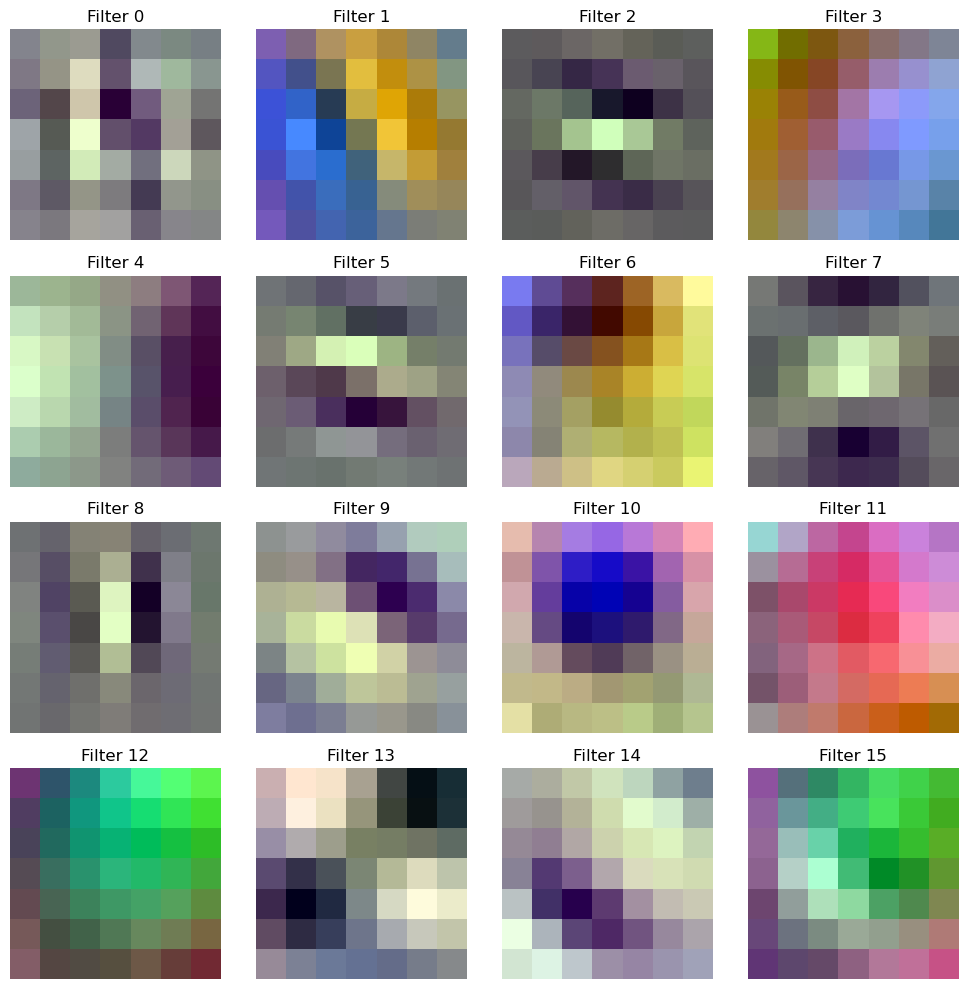

In [8]:
'''1. Obtain a pre-built CNN model such as SqueezeNet implementation that's part of `torchvision.models` and inspect/print/plot:
    * the architecture, and
    * the weights of the first convolutional layer.'''

import torchvision.models as models 
squeezenet = models.squeezenet1_0(pretrained=True)
print(squeezenet) #u get the full architecture printed out

#Get first conv layer
first_conv = squeezenet.features[0]
print(f"First conv layer: {first_conv}")

#Get the weights
weights = first_conv.weight.data.cpu().numpy()
print(f"Weights shape: {weights.shape}")

import matplotlib.pyplot as plt

#Visualize first 16 filter for edification
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < 16:
        # Get filter i, transpose to (height, width, channels) for display
        filter_img = weights[i].transpose(1, 2, 0)
        # Normalize to 0-1 range for display
        filter_img = (filter_img - filter_img.min()) / (filter_img.max() - filter_img.min())
        ax.imshow(filter_img)
        ax.set_title(f'Filter {i}')
        ax.axis('off')
plt.tight_layout()
plt.show()


1. Transfer-learn with this model to recognize an object of your choosing.
    1. Download http://cs231n.stanford.edu/tiny-imagenet-200.zip (237MB) If you want to train on full-size (224x224) images, you will need more substantial hardware than your laptop.
    1. Capture images (or download images) of your favorite object and replace one of the 200 object folders with yours.
   

Question 8 is a bit more involved. Feel free to use GenAI to help you with data loading and transformations, if needed. We will do a lab discussion (Q&A) on Monday, as well.

In [9]:
import os

# Check the dataset structure
train_dir = 'tiny-imagenet-200/train'
class_folders = os.listdir(train_dir)
print(f"Number of classes: {len(class_folders)}")
print(f"First few class folders: {class_folders[:5]}")

# Check how many images in first class
first_class = class_folders[0]
images_path = os.path.join(train_dir, first_class, 'images')
num_images = len(os.listdir(images_path))
print(f"\nImages in {first_class}: {num_images}")

Number of classes: 200
First few class folders: ['n01443537', 'n01629819', 'n01641577', 'n01644900', 'n01698640']

Images in n01443537: 147


In [ ]:


# Install the downloader
!pip install bing-image-downloader

# Download capybara images
from bing_image_downloader import downloader

downloader.download(
    query="capybara",
    limit=200,  #number of images
    output_dir=".",
    adult_filter_off=True,
    force_replace=False,
    timeout=60
)

In [10]:
import os

# Try the Windows path
capybara_path = r'C:\Users\jgooh\OneDrive - Naval Postgraduate School\CS4330 Computer Vision\Labs\capybara'

if os.path.exists(capybara_path):
    images = [f for f in os.listdir(capybara_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    print(f"Found {len(images)} capybara images")
else:
    print("Path not accessible from Jupyter")

Found 147 capybara images


In [11]:
import shutil

# Source: your capybara images
capybara_source = r'C:\Users\jgooh\OneDrive - Naval Postgraduate School\CS4330 Computer Vision\Labs\capybara'

# Target: replace the first class folder
class_to_replace = 'n01443537'
target_folder = f'tiny-imagenet-200/train/{class_to_replace}/images'

# Clear out the old images
for f in os.listdir(target_folder):
    os.remove(os.path.join(target_folder, f))

# Copy capybara images in
copied = 0
for img in os.listdir(capybara_source):
    if img.endswith(('.jpg', '.jpeg', '.png')):
        shutil.copy(
            os.path.join(capybara_source, img),
            os.path.join(target_folder, img)
        )
        copied += 1

print(f"Replaced {class_to_replace} with {copied} capybara images!")

# Verify
print(f"Images now in {class_to_replace}: {len(os.listdir(target_folder))}")

Replaced n01443537 with 147 capybara images!
Images now in n01443537: 147


 1. Instantiate a data loader that reads from the dataset folder. Make sure it can upscale the images to the SqueezeNet size. GenAI is your friend.
    1. Train for a few epochs, and evaluate in general and on your object, in particular.

In [12]:
'''So we need a data loader that reads images from the tiny-imaenet folders
Resize them to 224x224 which is squeezenet's expected input size
-we also want to apply data augmentation (random flips/crops) to help training on the images
-Then we want to normalize using the ImageNet statistics
-usually 
'''

from torchvision import transforms, datasets
from torch.utils.data import DataLoader
#Data loader combines a dataset and a sampler, and provides an iterable over the given dataset.
# Define transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(256),                          # Resize to slightly larger
        transforms.RandomCrop(224),                      # Random crop to 224x224
        transforms.RandomHorizontalFlip(),               # Random flip for augmentation
        transforms.ToTensor(),                           # Convert to tensor
        transforms.Normalize([0.485, 0.456, 0.406],     # ImageNet mean
                           [0.229, 0.224, 0.225])        # ImageNet std
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),                      # Center crop (no randomness for validation)
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                           [0.229, 0.224, 0.225])
    ])
}

# Create datasets
train_dataset = datasets.ImageFolder('tiny-imagenet-200/train', transform=data_transforms['train'])
val_dataset = datasets.ImageFolder('tiny-imagenet-200/val', transform=data_transforms['val'])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(val_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"\nClass {train_dataset.class_to_idx['n01443537']} is now capybaras!")

Training images: 99647
Validation images: 10000
Number of classes: 200

Class 0 is now capybaras!


the beauty of transfer learning is that SqueezeNet already learned how to "see" images from 1.2 million images. We teach it hey these are the patterns of features = capybara" so it doesn't need a ton of data.

The model will output 200 numbers (logits), one per class (maybe class 0 is 3.2,clas1 is -1.5). the highest number is the prediciton

We know that folder n01443537 is at the index 0, we know we put capybaras in that folder so when we get 0 as the prediction we take that as the model predicting capybaras (so when you evaluate, you look up model predicted 0 -> thats x -> thats capybara)

In [ ]:
# Load pre-trained SqueezeNet
squeezenet = models.squeezenet1_0(pretrained=True)

# OPTION 1: Freeze early layers (recommended for first run)
freeze_features = True  # Set to False for fine-tuning

if freeze_features:
    for param in squeezenet.features.parameters():
        param.requires_grad = False
    print("Early layers frozen - only training classifier")
else:
    print("Fine-tuning all layers")

# Replace final classifier layer for 200 classes
# SqueezeNet's classifier is: Conv2d(512, 1000, kernel_size=1)
# We need to change it to: Conv2d(512, 200, kernel_size=1)

squeezenet.classifier[1] = nn.Conv2d(512, 200, kernel_size=(1,1), stride=(1,1))
squeezenet.num_classes = 200 #nowe we will see 200 classes instead of 1000

print("\nModified classifier:")
print(squeezenet.classifier)

# Move to device
squeezenet = squeezenet.to(device)

Early layers frozen - only training classifier

Modified classifier:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Conv2d(512, 200, kernel_size=(1, 1), stride=(1, 1))
  (2): ReLU(inplace=True)
  (3): AdaptiveAvgPool2d(output_size=(1, 1))
)


this compared to the digit example:

-we have larger rgb images of size 224x224
-more classes of image possibilities - 200 vs 10


In [14]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

# Only optimize the classifier parameters (since features are frozen)
if freeze_features:
    optimizer = torch.optim.Adam(squeezenet.classifier.parameters(), lr=0.001)
else:
    optimizer = torch.optim.Adam(squeezenet.parameters(), lr=0.0001)  # Lower LR for fine-tuning

# Training function
def train_transfer(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    return running_loss / len(train_loader), 100 * correct / total

# Validation function
def validate_transfer(model, val_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return 100 * correct / total

# Train for a few epochs
num_epochs = 3
print("Starting transfer learning training...\n")

for epoch in range(num_epochs):
    train_loss, train_acc = train_transfer(squeezenet, train_loader, criterion, optimizer)
    val_acc = validate_transfer(squeezenet, val_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

print("\nTraining complete!")

Starting transfer learning training...

Epoch 1/3 - Loss: 2.9124, Train Acc: 35.00%, Val Acc: 0.00%


KeyboardInterrupt: 

In [16]:
# Evaluate capybara-specific performance
def evaluate_capybara(model, data_loader, capybara_class_idx):
    model.eval()
    capybara_correct = 0
    capybara_total = 0
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            # Filter for capybara class only
            mask = labels == capybara_class_idx
            if mask.sum() > 0:
                capybara_correct += (predicted[mask] == labels[mask]).sum().item()
                capybara_total += mask.sum().item()
    
    if capybara_total > 0:
        print(f"Capybara accuracy: {100*capybara_correct/capybara_total:.2f}% ({capybara_correct}/{capybara_total})")
    else:
        print("No capybara images found")

# Find capybara class index and evaluate
capybara_idx = train_dataset.class_to_idx['n01443537']
print(f"Capybara is class index: {capybara_idx}")
print("\nEvaluating on training set:")
evaluate_capybara(squeezenet, train_loader, capybara_idx)

Capybara is class index: 0

Evaluating on training set:
Capybara accuracy: 97.96% (144/147)
